# Notebook for Exploratory Data Analysis
### For Analyzing Bias after Vision Zero

In [1]:
# install packages if necessary
%pip install -r "../requirements.txt"

ERROR: Could not open requirements file: [Errno 2] No such file or directory: '../requirements.txt'

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import geopandas as gpd
import zipfile

### Function to load data
- Loads in police stop data from the [Stanford Opening Policing Project](https://openpolicing.stanford.edu/data/)
- Data has been cleaned in the stop preprocessing notebook 

In [12]:
def load_data(path, lat = None, long = None, geospatial = False):
    # path is the string of the path to datafile
    # lat/long are strings for the name of the latitude and longitude columns in the datafile
    # set geospatial to true if trying to extract xy coordinates from a csv file
    
    # unzip data if name ends with .zip
    if(path[-3:]=="zip"):
        with zipfile.ZipFile(path) as z:
            csv_file = [f for f in z.namelist() if f.endswith(".csv")][0]
            df = pd.read_csv(z.open(csv_file))
        print("Unzipped")
    # read in regularly for non zipped files
    else:
        # split into last file name after /
        if("geojson" in path.rsplit('/', 1)[-1]):
            df = gpd.read_file(path)
        else:
            df = pd.read_csv(path)

    # convert to a geospatial dataframe to extract x,y coordinates
    if(geospatial):
        df = gpd.GeoDataFrame(
            df,
            geometry=gpd.points_from_xy(df[long], df[lat]),
            # crs set for lat/long data
            crs="EPSG:4326" 
        )

        # Print coordinate reference system to verify correct locations
        print("Data CRS:", df.crs)
    
    return df

In [13]:
stops_path = r"./data/stops_clean.csv.zip"
stops_df = load_data(stops_path)

Unzipped


In [14]:
stops_df.head()

,Unnamed: 0,date,time,lat,lng,subject_age,subject_race,subject_sex,arrest_made,citation_issued,...,collision,motor_assist,mpc,bolo,district_left,district_right,pct_over75,pct_poc,pct_disab,epc_class
0,359092,2010-01-01,00:10:00,37.744642,-122.424567,34.0,other,female,False,True,...,0,0,0,0,INGLESIDE,INGLESIDE,0.039024,0.250610,0.056098,NaN
1,359093,2010-01-01,00:10:00,37.782744,-122.406499,22.0,other,male,False,True,...,0,0,0,0,SOUTHERN,SOUTHERN,0.032678,0.726959,0.228348,High
2,359094,2010-01-01,01:00:00,37.763301,-122.480603,27.0,asian/pacific islander,female,False,True,...,0,0,0,0,TARAVAL,TARAVAL,0.053179,0.651997,0.095762,NaN
3,359095,2010-01-01,01:00:00,37.770318,-122.452079,25.0,hispanic,female,False,False,...,0,0,0,0,PARK,PARK,0.017103,0.310707,0.075717,NaN
4,359096,2010-01-01,10:00:00,37.765696,-122.470729,36.0,white,male,False,True,...,0,0,0,0,TARAVAL,TARAVAL,0.044363,0.542523,0.034408,NaN


In [15]:
# Recode NAs to 'None' for epc_class
stops_df['epc_class'].fillna('None')

0         None
1         High
2         None
3         None
4         None
          ... 
514771    None
514772    High
514773    None
514774    None
514775    None
Name: epc_class, Length: 514776, dtype: str

In [16]:
stops_df.head()

,Unnamed: 0,date,time,lat,lng,subject_age,subject_race,subject_sex,arrest_made,citation_issued,...,collision,motor_assist,mpc,bolo,district_left,district_right,pct_over75,pct_poc,pct_disab,epc_class
0,359092,2010-01-01,00:10:00,37.744642,-122.424567,34.0,other,female,False,True,...,0,0,0,0,INGLESIDE,INGLESIDE,0.039024,0.250610,0.056098,NaN
1,359093,2010-01-01,00:10:00,37.782744,-122.406499,22.0,other,male,False,True,...,0,0,0,0,SOUTHERN,SOUTHERN,0.032678,0.726959,0.228348,High
2,359094,2010-01-01,01:00:00,37.763301,-122.480603,27.0,asian/pacific islander,female,False,True,...,0,0,0,0,TARAVAL,TARAVAL,0.053179,0.651997,0.095762,NaN
3,359095,2010-01-01,01:00:00,37.770318,-122.452079,25.0,hispanic,female,False,False,...,0,0,0,0,PARK,PARK,0.017103,0.310707,0.075717,NaN
4,359096,2010-01-01,10:00:00,37.765696,-122.470729,36.0,white,male,False,True,...,0,0,0,0,TARAVAL,TARAVAL,0.044363,0.542523,0.034408,NaN


In [21]:
stops_df["date"] = pd.to_datetime(stops_df["date"])
stops_df["year"] = stops_df["date"].dt.year

In [23]:
stops_by_year = (
    stops_df.groupby(["year", "subject_race"])
      .size()
      .reset_index(name="stops")
)

In [24]:
stops_by_year

,year,subject_race,stops
0,2010,asian/pacific islander,15964
1,2010,black,16636
2,2010,hispanic,11839
3,2010,other,11253
4,2010,white,46972
5,2011,asian/pacific islander,17408
6,2011,black,15921
7,2011,hispanic,13313
8,2011,other,9889
9,2011,white,41910


In [26]:

# SF demographic breakdown from 2010 census
population = {
    "white": 337451,
    "black": 46751,
    "asian/pacific islander": 265700 + 3128,
    "other": 28573,
    "hispanic": 121774
}
stops_by_year["population"] = stops_by_year["subject_race"].map(population)

stops_by_year["stops_per_1000"] = stops_by_year["stops"] / stops_by_year["population"] * 10000

In [27]:
stops_by_year

,year,subject_race,stops,population,stops_per_1000
0,2010,asian/pacific islander,15964,268828,593.836952
1,2010,black,16636,46751,3558.426558
2,2010,hispanic,11839,121774,972.210817
3,2010,other,11253,28573,3938.333392
4,2010,white,46972,337451,1391.965056
5,2011,asian/pacific islander,17408,268828,647.551594
6,2011,black,15921,46751,3405.488653
7,2011,hispanic,13313,121774,1093.254718
8,2011,other,9889,28573,3460.959647
9,2011,white,41910,337451,1241.958092


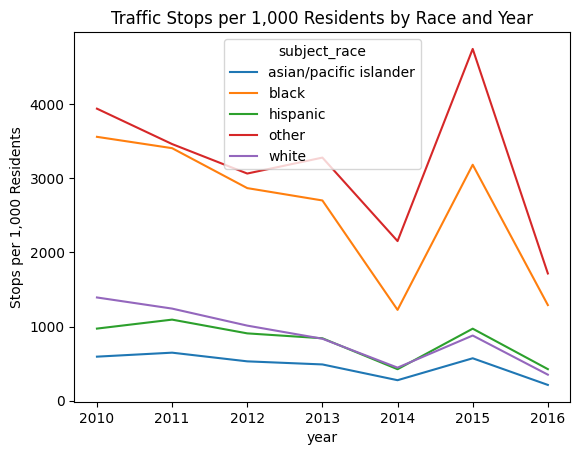

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=stops_by_year,
    x="year",
    y="stops_per_1000",
    hue="subject_race"
)

plt.ylabel("Stops per 1,000 Residents")
plt.title("Traffic Stops per 1,000 Residents by Race")
plt.show()